# Methode de Box-Jenkins - Ventes mensuelles de voitures au Quebec

Objectif: construire un modele SARIMA simple pour prevoir les ventes mensuelles de voitures.  
La serie couvre janvier 1960 a decembre 1968. On garde 1967-1968 comme validation.


In [1]:
from pathlib import Path
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'ventes_voitures_quebec.txt'
FIG = ROOT / 'figures'
OUT = ROOT / 'outputs'
FIG.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)


## 1. Chargement des donnees

On cree une serie temporelle mensuelle avec une frequence fixe.

In [2]:
df = pd.read_csv(DATA, sep='\t')
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month').asfreq('MS')
y = df['Sales'].astype(float)

display(df.head())
print(y.describe())


,Sales
Month,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


count      108.000000
mean     15396.009259
std       5451.867324
min       6550.000000
25%      11300.000000
50%      14493.500000
75%      18152.000000
max      29500.000000
Name: Sales, dtype: float64


## 2. Visualisation et decoupage

Le modele est estime sur 1960-1966 et valide sur 1967-1968.

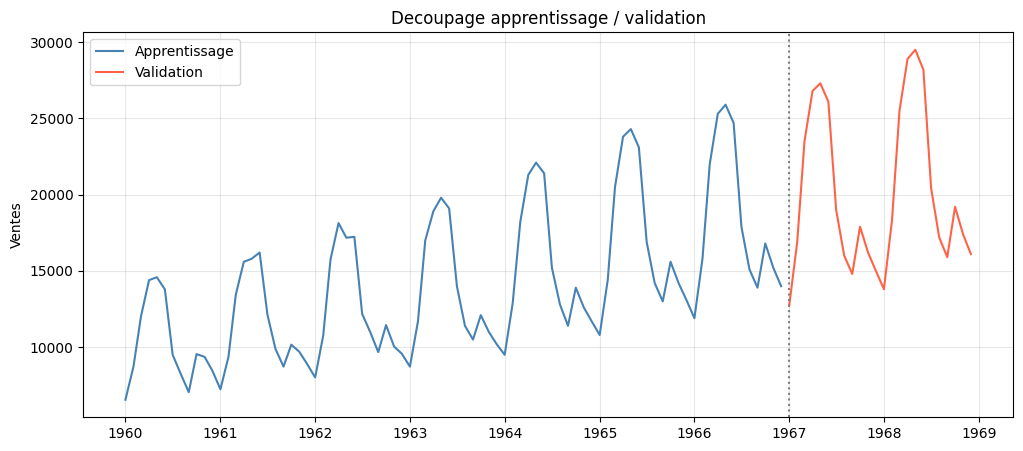

Taille apprentissage: 84
Taille validation: 24


In [3]:
train = y.loc[:'1966-12']
test = y.loc['1967-01':]

fig, ax = plt.subplots()
ax.plot(train.index, train, label='Apprentissage', color='steelblue')
ax.plot(test.index, test, label='Validation', color='tomato')
ax.axvline(test.index[0], color='gray', linestyle=':')
ax.set_title('Decoupage apprentissage / validation')
ax.set_ylabel('Ventes')
ax.legend()
plt.show()

print('Taille apprentissage:', len(train))
print('Taille validation:', len(test))


## 3. Analyse qualitative

On observe une tendance croissante et une saisonnalite annuelle. La decomposition multiplicative convient car l'amplitude des variations augmente avec le niveau de la serie.

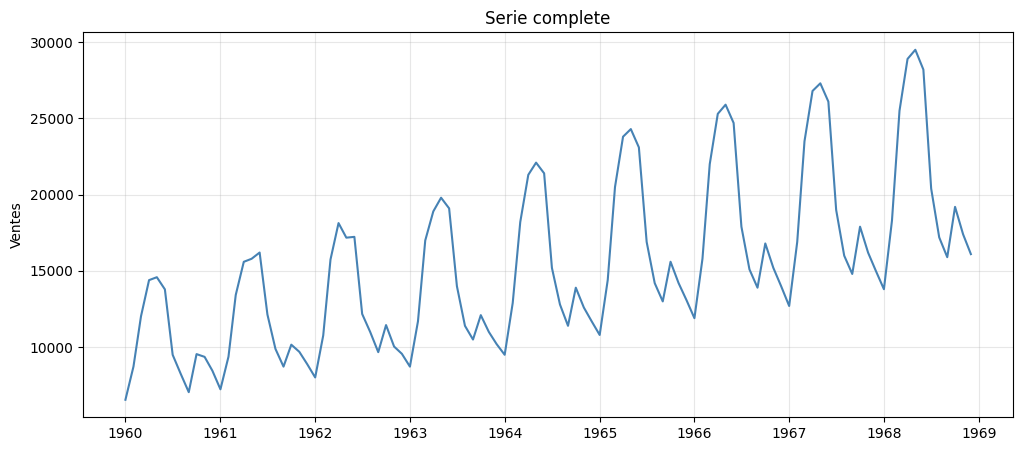

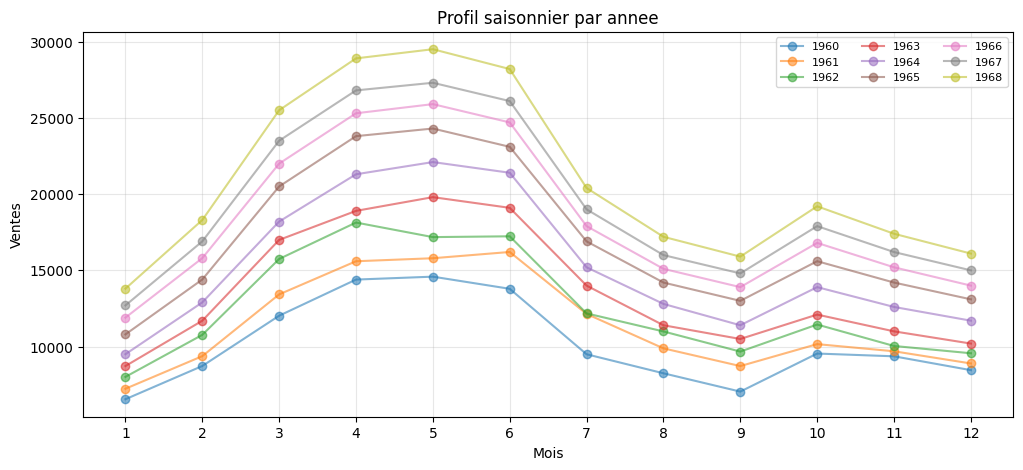

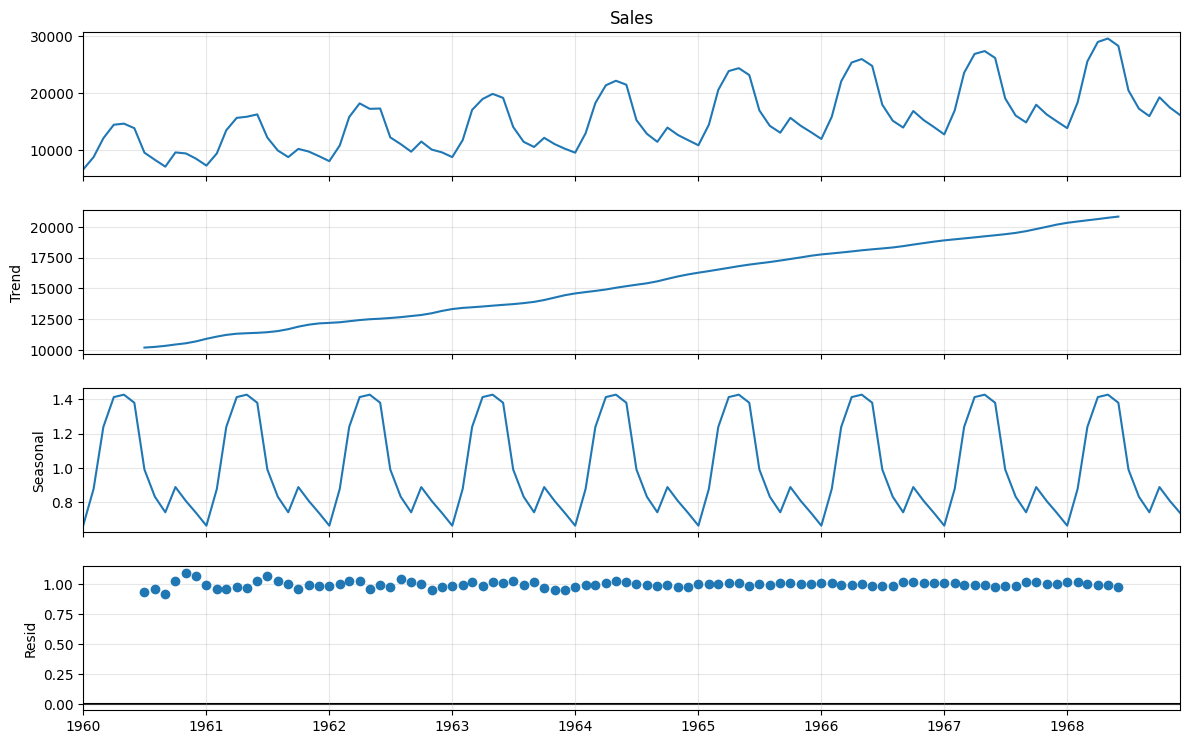

In [4]:
fig, ax = plt.subplots()
ax.plot(y.index, y, color='steelblue')
ax.set_title('Serie complete')
ax.set_ylabel('Ventes')
plt.show()

monthly = pd.DataFrame({'Sales': y})
monthly['annee'] = monthly.index.year
monthly['mois'] = monthly.index.month
fig, ax = plt.subplots()
for year, group in monthly.groupby('annee'):
    ax.plot(group['mois'], group['Sales'], marker='o', alpha=0.55, label=str(year))
ax.set_xticks(range(1, 13))
ax.set_title('Profil saisonnier par annee')
ax.set_xlabel('Mois')
ax.set_ylabel('Ventes')
ax.legend(ncol=3, fontsize=8)
plt.show()

seasonal_decompose(y, model='multiplicative', period=12).plot();
plt.gcf().set_size_inches(12, 8)
plt.show()


## 4. Stationnarite

On teste la serie brute, le logarithme, la difference ordinaire et la difference ordinaire + saisonniere.

In [5]:
def stationarity_test(name, series):
    clean = series.dropna()
    adf = adfuller(clean, autolag='AIC')
    kp = kpss(clean, regression='c', nlags='auto')
    return {
        'serie': name,
        'ADF stat': adf[0],
        'ADF p-value': adf[1],
        'KPSS stat': kp[0],
        'KPSS p-value': kp[1],
    }

tests = pd.DataFrame([
    stationarity_test('Serie brute', train),
    stationarity_test('log(Y)', np.log(train)),
    stationarity_test('Delta log(Y)', np.log(train).diff()),
    stationarity_test('Delta Delta_12 log(Y)', np.log(train).diff().diff(12)),
])
display(tests.round(4))

def interpretation(row):
    adf_ok = row['ADF p-value'] < 0.05
    kpss_ok = row['KPSS p-value'] > 0.05
    return 'stationnaire' if adf_ok and kpss_ok else 'non stationnaire'

tests['interpretation'] = tests.apply(interpretation, axis=1)
display(tests[['serie', 'interpretation']])


,serie,ADF stat,ADF p-value,KPSS stat,KPSS p-value
0,Serie brute,0.6435,0.9886,0.8558,0.01
1,log(Y),-1.0958,0.7168,0.9327,0.01
2,Delta log(Y),-4.4701,0.0002,0.0382,0.10
3,Delta Delta_12 log(Y),-3.4670,0.0089,0.0203,0.10


,serie,interpretation
0,Serie brute,non stationnaire
1,log(Y),non stationnaire
2,Delta log(Y),stationnaire
3,Delta Delta_12 log(Y),stationnaire


## 5. ACF et PACF

Les correlogrammes sont traces jusqu'au retard K = 36, conformement a l'enonce.

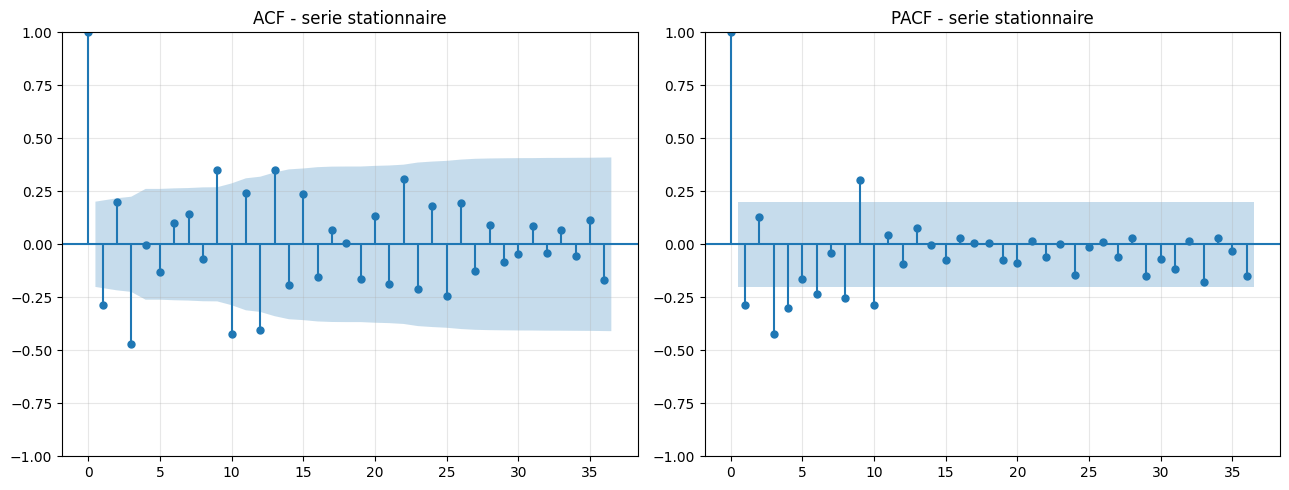

In [6]:
stationary = np.log(y).diff().diff(12).dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_acf(stationary, lags=36, ax=axes[0])
plot_pacf(stationary, lags=36, ax=axes[1], method='ywm')
axes[0].set_title('ACF - serie stationnaire')
axes[1].set_title('PACF - serie stationnaire')
plt.tight_layout()
plt.show()


## 6. Recherche du modele SARIMA

On cherche un modele SARIMA(p,1,q)(P,1,Q)[12]. Les ordres sont limites pour garder un modele presentable.

In [7]:
records = []
log_train = np.log(train)

for p, q, P, Q in itertools.product(range(4), range(4), range(2), range(2)):
    try:
        model = SARIMAX(
            log_train,
            order=(p, 1, q),
            seasonal_order=(P, 1, Q, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(disp=False, maxiter=300)
        fc = fitted.get_forecast(steps=len(test))
        pred = np.exp(fc.predicted_mean)
        pred.index = test.index
        lb = acorr_ljungbox(fitted.resid.dropna(), lags=[12, 24], return_df=True)
        records.append({
            'modele': f'SARIMA({p},1,{q})({P},1,{Q})[12]',
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'LjungBox p(12)': lb['lb_pvalue'].iloc[0],
            'LjungBox p(24)': lb['lb_pvalue'].iloc[1],
            'MAE': mean_absolute_error(test, pred),
            'RMSE': mean_squared_error(test, pred) ** 0.5,
            'MAPE': np.mean(np.abs((test - pred) / test)) * 100,
        })
    except Exception:
        pass

selection = pd.DataFrame(records).sort_values('AIC').reset_index(drop=True)
display(selection.head(10).round(4))


,modele,AIC,BIC,LjungBox p(12),LjungBox p(24),MAE,RMSE,MAPE
0,"SARIMA(3,1,1)(0,1,0)[12]",-261.2515,-250.1539,0.0395,0.5874,159.9909,200.8913,0.7346
1,"SARIMA(3,1,2)(0,1,0)[12]",-259.2566,-245.9396,0.0390,0.5846,155.8293,197.0304,0.7155
2,"SARIMA(0,1,3)(0,1,0)[12]",-256.5331,-247.7143,0.0377,0.5784,916.9940,1022.1766,4.3830
3,"SARIMA(0,1,3)(1,1,0)[12]",-256.2883,-245.9006,0.0778,0.7248,993.0282,1094.7577,4.7590
4,"SARIMA(3,1,3)(0,1,0)[12]",-254.8168,-239.3839,0.0400,0.5899,949.0446,1053.2459,4.5303
5,"SARIMA(1,1,3)(0,1,0)[12]",-254.5760,-243.5525,0.0382,0.5807,913.8901,1019.8331,4.3661
6,"SARIMA(3,1,0)(0,1,1)[12]",-252.0319,-241.7297,0.0093,0.2462,587.2846,676.5640,2.7479
7,"SARIMA(2,1,3)(0,1,0)[12]",-251.6787,-238.4506,0.0366,0.5720,901.1163,1003.2690,4.3145
8,"SARIMA(1,1,3)(1,1,0)[12]",-251.2369,-238.8742,0.0442,0.5578,978.2065,1076.3313,4.6941
9,"SARIMA(3,1,0)(0,1,0)[12]",-251.0429,-242.1649,0.0477,0.6252,114.6340,163.4915,0.5538


## 7. Estimation du modele retenu

Le meilleur modele par AIC est SARIMA(3,1,1)(0,1,0)[12].

In [8]:
selected = SARIMAX(
    log_train,
    order=(3, 1, 1),
    seasonal_order=(0, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=300)

print(selected.summary())


                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   84
Model:             SARIMAX(3, 1, 1)x(0, 1, [], 12)   Log Likelihood                 135.626
Date:                             Sat, 09 May 2026   AIC                           -261.251
Time:                                     21:30:58   BIC                           -250.154
Sample:                                 01-01-1960   HQIC                          -256.854
                                      - 12-01-1966                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3187      0.100      3.192      0.001       0.123       0.514
ar.L2          0.1486      

## 8. Diagnostics des residus

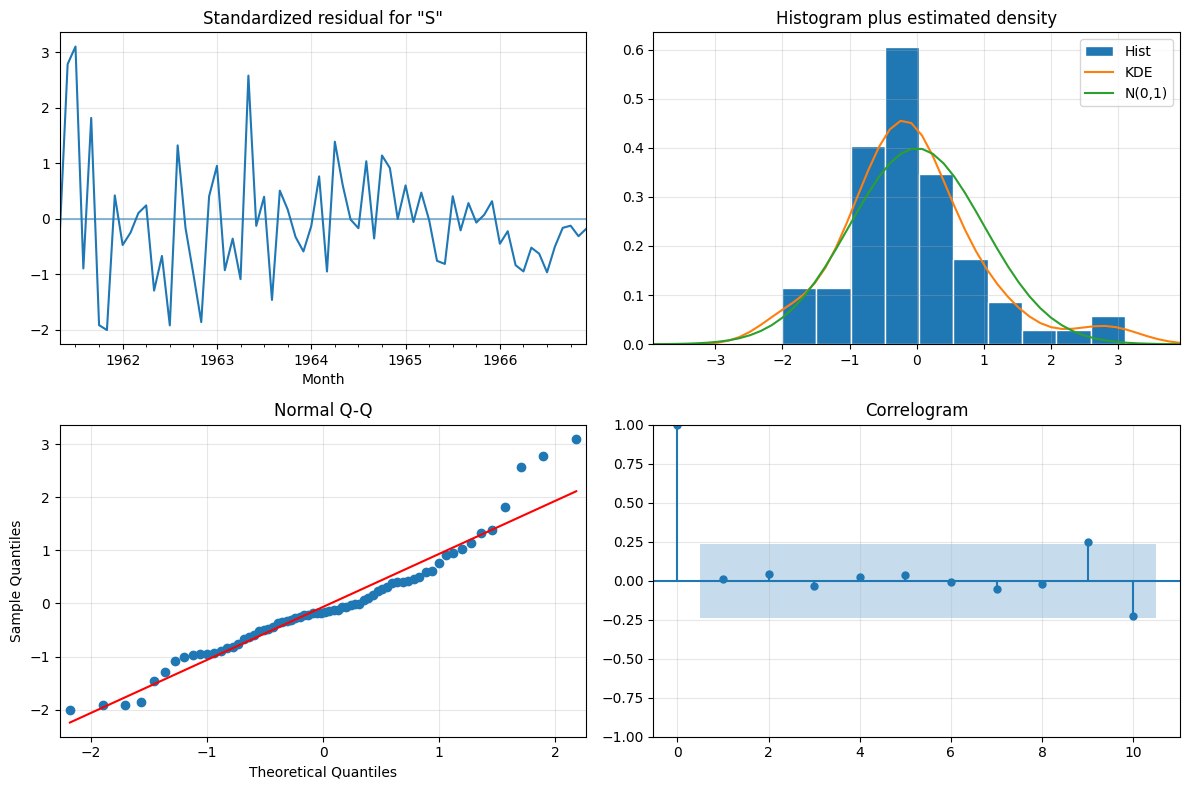

,lb_stat,lb_pvalue
12,21.8270,0.0395
24,21.8634,0.5874


In [9]:
selected.plot_diagnostics(figsize=(12, 8));
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(selected.resid.dropna(), lags=[12, 24], return_df=True)
display(lb.round(4))


## 9. Validation sur 1967-1968

,MAE,RMSE,MAPE
0,159.991,200.891,0.735


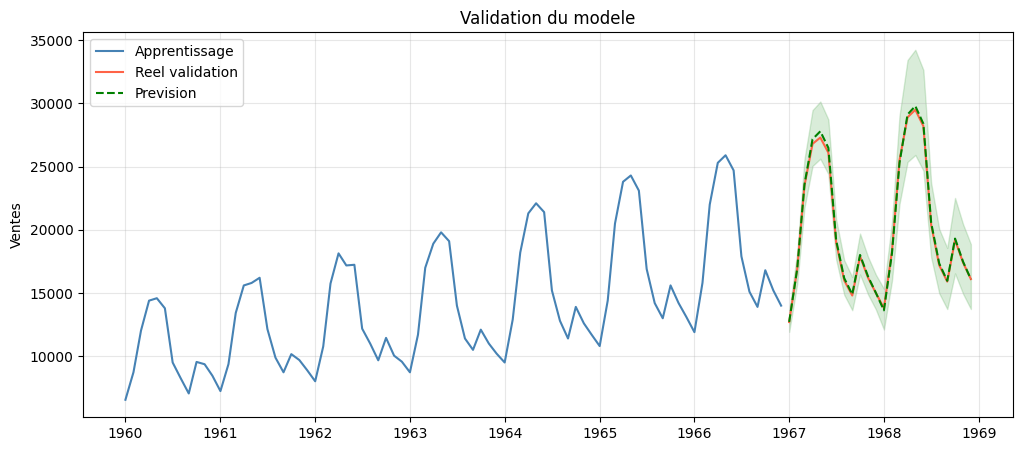

In [10]:
forecast = selected.get_forecast(steps=len(test))
pred = np.exp(forecast.predicted_mean)
ci = np.exp(forecast.conf_int(alpha=0.05))
pred.index = test.index
ci.index = test.index

metrics = pd.DataFrame([{
    'MAE': mean_absolute_error(test, pred),
    'RMSE': mean_squared_error(test, pred) ** 0.5,
    'MAPE': np.mean(np.abs((test - pred) / test)) * 100,
}])
display(metrics.round(3))

fig, ax = plt.subplots()
ax.plot(train.index, train, label='Apprentissage', color='steelblue')
ax.plot(test.index, test, label='Reel validation', color='tomato')
ax.plot(pred.index, pred, label='Prevision', color='green', linestyle='--')
ax.fill_between(pred.index, ci.iloc[:, 0], ci.iloc[:, 1], color='green', alpha=0.15)
ax.legend()
ax.set_title('Validation du modele')
ax.set_ylabel('Ventes')
plt.show()


## 10. Prevision finale pour 1969

On reestime le modele sur toute la serie, puis on prevoit les 12 mois suivants.

,prevision,borne_inf,borne_sup
1969-01-01,14844.0,14043.0,15691.0
1969-02-01,19683.0,18472.0,20973.0
1969-03-01,27444.0,25571.0,29455.0
1969-04-01,31076.0,28954.0,33352.0
1969-05-01,31716.0,29550.0,34041.0
1969-06-01,30303.0,28233.0,32525.0
1969-07-01,21927.0,20406.0,23562.0
1969-08-01,18489.0,17177.0,19902.0
1969-09-01,17097.0,15837.0,18457.0
1969-10-01,20645.0,19094.0,22323.0


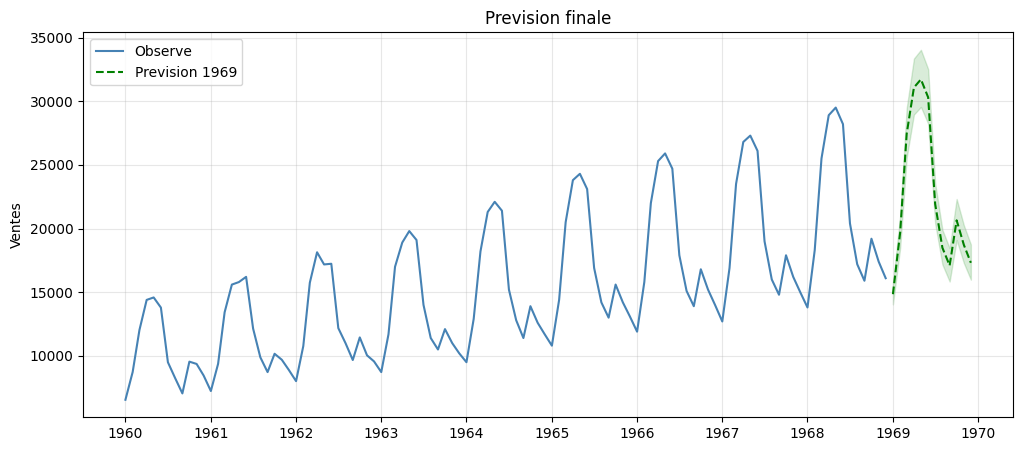

In [11]:
final_model = SARIMAX(
    np.log(y),
    order=(3, 1, 1),
    seasonal_order=(0, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=300)

future_fc = final_model.get_forecast(steps=12)
future = np.exp(future_fc.predicted_mean)
future.index = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')
future_ci = np.exp(future_fc.conf_int(alpha=0.05))
future_ci.index = future.index

future_table = pd.DataFrame({
    'prevision': future,
    'borne_inf': future_ci.iloc[:, 0],
    'borne_sup': future_ci.iloc[:, 1],
})
display(future_table.round(0))

fig, ax = plt.subplots()
ax.plot(y.index, y, label='Observe', color='steelblue')
ax.plot(future.index, future, label='Prevision 1969', color='green', linestyle='--')
ax.fill_between(future.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color='green', alpha=0.15)
ax.legend()
ax.set_title('Prevision finale')
ax.set_ylabel('Ventes')
plt.show()


## Conclusion rapide

La serie possede une tendance et une saisonnalite annuelle. Apres logarithme et deux differenciations, le modele SARIMA(3,1,1)(0,1,0)[12] fournit une validation tres correcte avec un MAPE inferieur a 1 %.